In [86]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors        import KNeighborsClassifier
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import classification_report, confusion_matrix
import streamlit as st
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [94]:
# ── 1. Load dataset ──
df_raw= pd.read_csv("/Users/ds39/PycharmProjects/MAVE_Project/final_combined_plasmid_data_cleaned.csv")
print(df_raw.columns)

Index(['Hdr Vector Lot', 'Pass Fail', 'Gini Coefficient', 'Total Reads',
       'Accepted Reads', '% Reference Reads', '% PAM Reads',
       '% Unmapped Reads', '% Library Reads', '% Correct Size Insert',
       'Library Coverage', 'Library Size', '% Missing Library Sequence',
       'HDR_nanodrop (ng/ul)', 'HDR_A260/A280', 'HDR_A260/A230',
       'HDR_Qubit(ng/ul)', 'HDR_actual_DNA', 'gRNA_nanodrop (ng/ul)',
       'gRNA_A260/A280', 'gRNA_A260/A230', 'gRNA_Qubit (ng/ul)',
       'gRNA_actual_DNA', 'Per_Million_TotalDNA', 'Average_mapped_reads',
       'Average_TransfectionEfficency_GFP', 'Average_Cell_Count',
       'Average_Total_Cells', '%_Surviving_Cells', 'Estimated_Edited_Cells',
       '%_Successful_Edited_Cells'],
      dtype='object')


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_62883/986933267.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda v: v[0] if isinstance(v, (list, np.ndarray)) and len(v) > 0 else v)


✅ Final X shape: (52, 26)
✅ Columns in X: ['Gini Coefficient', 'Total Reads', 'Accepted Reads', '% Reference Reads', '% PAM Reads', '% Unmapped Reads', '% Library Reads', '% Correct Size Insert', 'Library Coverage', 'Library Size', '% Missing Library Sequence', 'HDR_A260/A280', 'HDR_A260/A230', 'HDR_Qubit(ng/ul)', 'HDR_actual_DNA', 'gRNA_A260/A280', 'gRNA_A260/A230', 'gRNA_Qubit (ng/ul)', 'gRNA_actual_DNA', 'Per_Million_TotalDNA', 'Average_TransfectionEfficency_GFP', 'Average_Cell_Count', 'Average_Total_Cells', '%_Surviving_Cells', 'Estimated_Edited_Cells', '%_Successful_Edited_Cells']


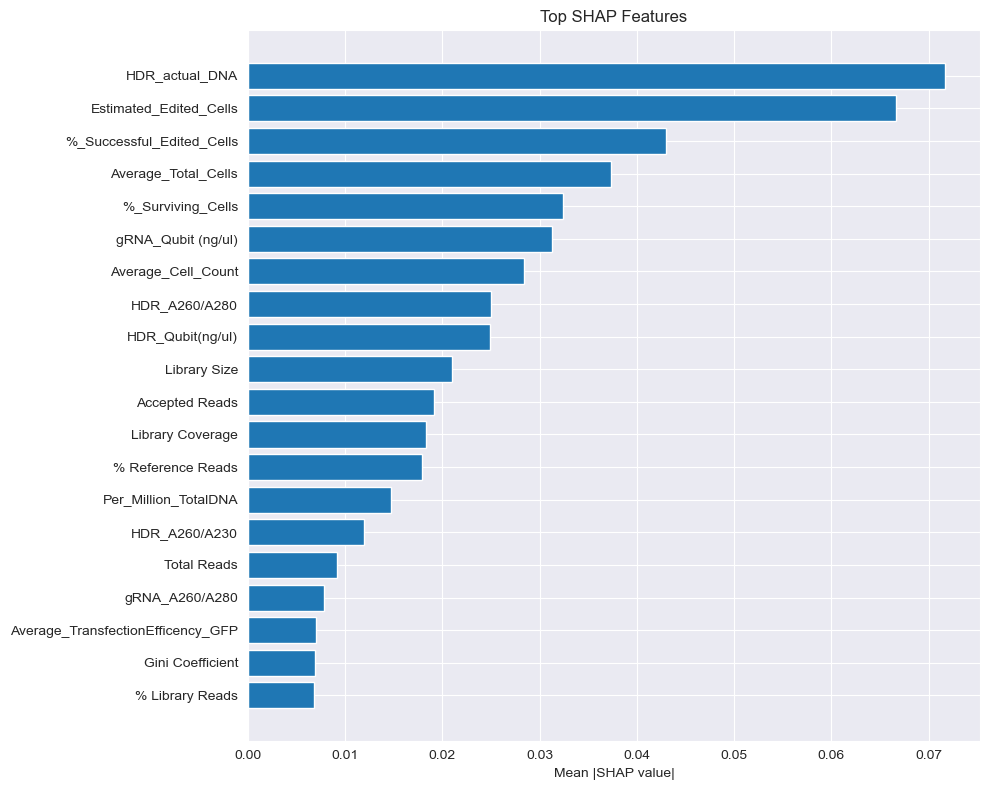

✅ SHAP analysis complete. Plots and CSVs saved.


In [98]:
# ── 1. Load raw data ──
df_raw = pd.read_csv("/Users/ds39/PycharmProjects/MAVE_Project/final_combined_plasmid_data_cleaned.csv")
# ── 2. Clean column names (in case of trailing spaces) ──
df_raw.columns = df_raw.columns.str.strip()

# ── 3. Extract target ──
if "Average_mapped_reads" not in df_raw.columns:
    raise ValueError("Target column 'Average_mapped_reads' missing!")
y = (df_raw["Average_mapped_reads"] > 40).astype(int)

# ── 4. Drop leakage or misleading features ──
leak_cols = [
    "Hdr Vector Lot", "Pass Fail", "Average_mapped_reads",
    "HDR_nanodrop (ng/ul)", "gRNA_nanodrop (ng/ul)"
]
df = df_raw.drop(columns=[col for col in leak_cols if col in df_raw.columns], errors="ignore")

# ── 5. Flatten and convert to numeric ──
df = df.applymap(lambda v: v[0] if isinstance(v, (list, np.ndarray)) and len(v) > 0 else v)
df = df.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

# ── 6. Align target length ──
y = y.iloc[:len(df)].reset_index(drop=True)
X = df.copy()

# ── 7. Sanity check ──
assert "HDR_nanodrop (ng/ul)" not in X.columns
assert "gRNA_nanodrop (ng/ul)" not in X.columns
assert "Average_mapped_reads" not in X.columns

print("✅ Final X shape:", X.shape)
print("✅ Columns in X:", X.columns.tolist())

# ── 8. Train/test split ──
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=0
)

# ── 9. Train Random Forest ──
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

# ── 10. SHAP analysis ──
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_valid)

# Select class 1 if binary
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# ── 11. SHAP feature importance ──
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(by="MeanAbsSHAP", ascending=False)

# ── 12. SHAP bar plot ──
top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance["Feature"].head(top_n)[::-1],
    feature_importance["MeanAbsSHAP"].head(top_n)[::-1]
)
plt.xlabel("Mean |SHAP value|")
plt.title("Top SHAP Features")
plt.tight_layout()
plt.savefig("shap_top_features_barplot.png", dpi=300)
plt.show()

# ── 13. SHAP beeswarm plot ──
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_valid,
    feature_names=X.columns,
    show=False,
    plot_type="dot"
)
plt.subplots_adjust(left=0.3)
fig.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.close(fig)

print("✅ SHAP analysis complete. Plots and CSVs saved.")


In [ ]:

# build target y = Pass if Average_mapped_reads > 40
y = (df_full["Average_mapped_reads"] > 40).astype(int).iloc[:len(df)].reset_index(drop=True)
X = df.copy()

print(f"Data matrix X: {X.shape},  y: {y.value_counts().to_dict()}")

# ── 2. Train/Test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=0
)

# ── 3. Define models ──
classifiers = {
    'KNN (k=5)'         : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'         : SVC(kernel='rbf', probability=True, random_state=0),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=0),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=0),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=0)
}

# ensure output folder
os.makedirs("model_outputs", exist_ok=True)

# ── 4. Run CV & test eval ──
results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for name, clf in classifiers.items():
    print(f"\n=== {name} ===")
    
    # cross‐val accuracy
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='accuracy')
    
    # train on full train set, eval on test set
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # store summary
    results.append({
        "Model"       : name,
        "CV Mean Acc" : np.mean(cv_scores),
        "CV Std Acc"  : np.std(cv_scores),
        "Test Acc"    : (y_pred == y_test).mean()
    })
    
    # detailed metrics
    print(classification_report(y_test, y_pred, target_names=["Fail","Pass"]))
    
    # confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fail","Pass"], yticklabels=["Fail","Pass"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"model_outputs/{name.replace(' ','_')}_confusion_matrix.png", dpi=300)
    plt.close()

# ── 5. Write summary CSV ──
df_results = pd.DataFrame(results)
df_results.to_csv("model_outputs/model_zoo_comparison_results.csv", index=False)
print("\nSummary saved to model_outputs/model_zoo_comparison_results.csv")
print(df_results)
